In [1]:
from ultralytics import YOLO
import cv2
import os
from IPython.display import Image, display

In [2]:
model = YOLO("yolov8n.pt")

In [3]:
os.makedirs("output_images", exist_ok=True)
os.makedirs("output_videos", exist_ok=True)

In [4]:
image_folder = "images"

image_files = [
    f for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for image_name in image_files:
    
    image_path = os.path.join(image_folder, image_name)
    results = model(image_path)
    output_path = os.path.join("output_images", image_name)
    results[0].save(filename=output_path)

    print(f"Processed: {image_name}")


image 1/1 C:\Users\Localws\images\image1.jpg: 480x640 1 book, 632.2ms
Speed: 16.9ms preprocess, 632.2ms inference, 8.5ms postprocess per image at shape (1, 3, 480, 640)
Processed: image1.jpg

image 1/1 C:\Users\Localws\images\image10.jpg: 416x640 1 potted plant, 1 laptop, 1 vase, 527.2ms
Speed: 13.7ms preprocess, 527.2ms inference, 5.7ms postprocess per image at shape (1, 3, 416, 640)
Processed: image10.jpg

image 1/1 C:\Users\Localws\images\image2.jpg: 640x480 1 bicycle, 620.0ms
Speed: 14.9ms preprocess, 620.0ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 480)
Processed: image2.jpg

image 1/1 C:\Users\Localws\images\image3.jpg: 448x640 2 laptops, 548.2ms
Speed: 12.2ms preprocess, 548.2ms inference, 4.3ms postprocess per image at shape (1, 3, 448, 640)
Processed: image3.jpg

image 1/1 C:\Users\Localws\images\image4.jpg: 512x640 1 bird, 4 kites, 973.2ms
Speed: 20.0ms preprocess, 973.2ms inference, 6.3ms postprocess per image at shape (1, 3, 512, 640)
Processed: image4.j

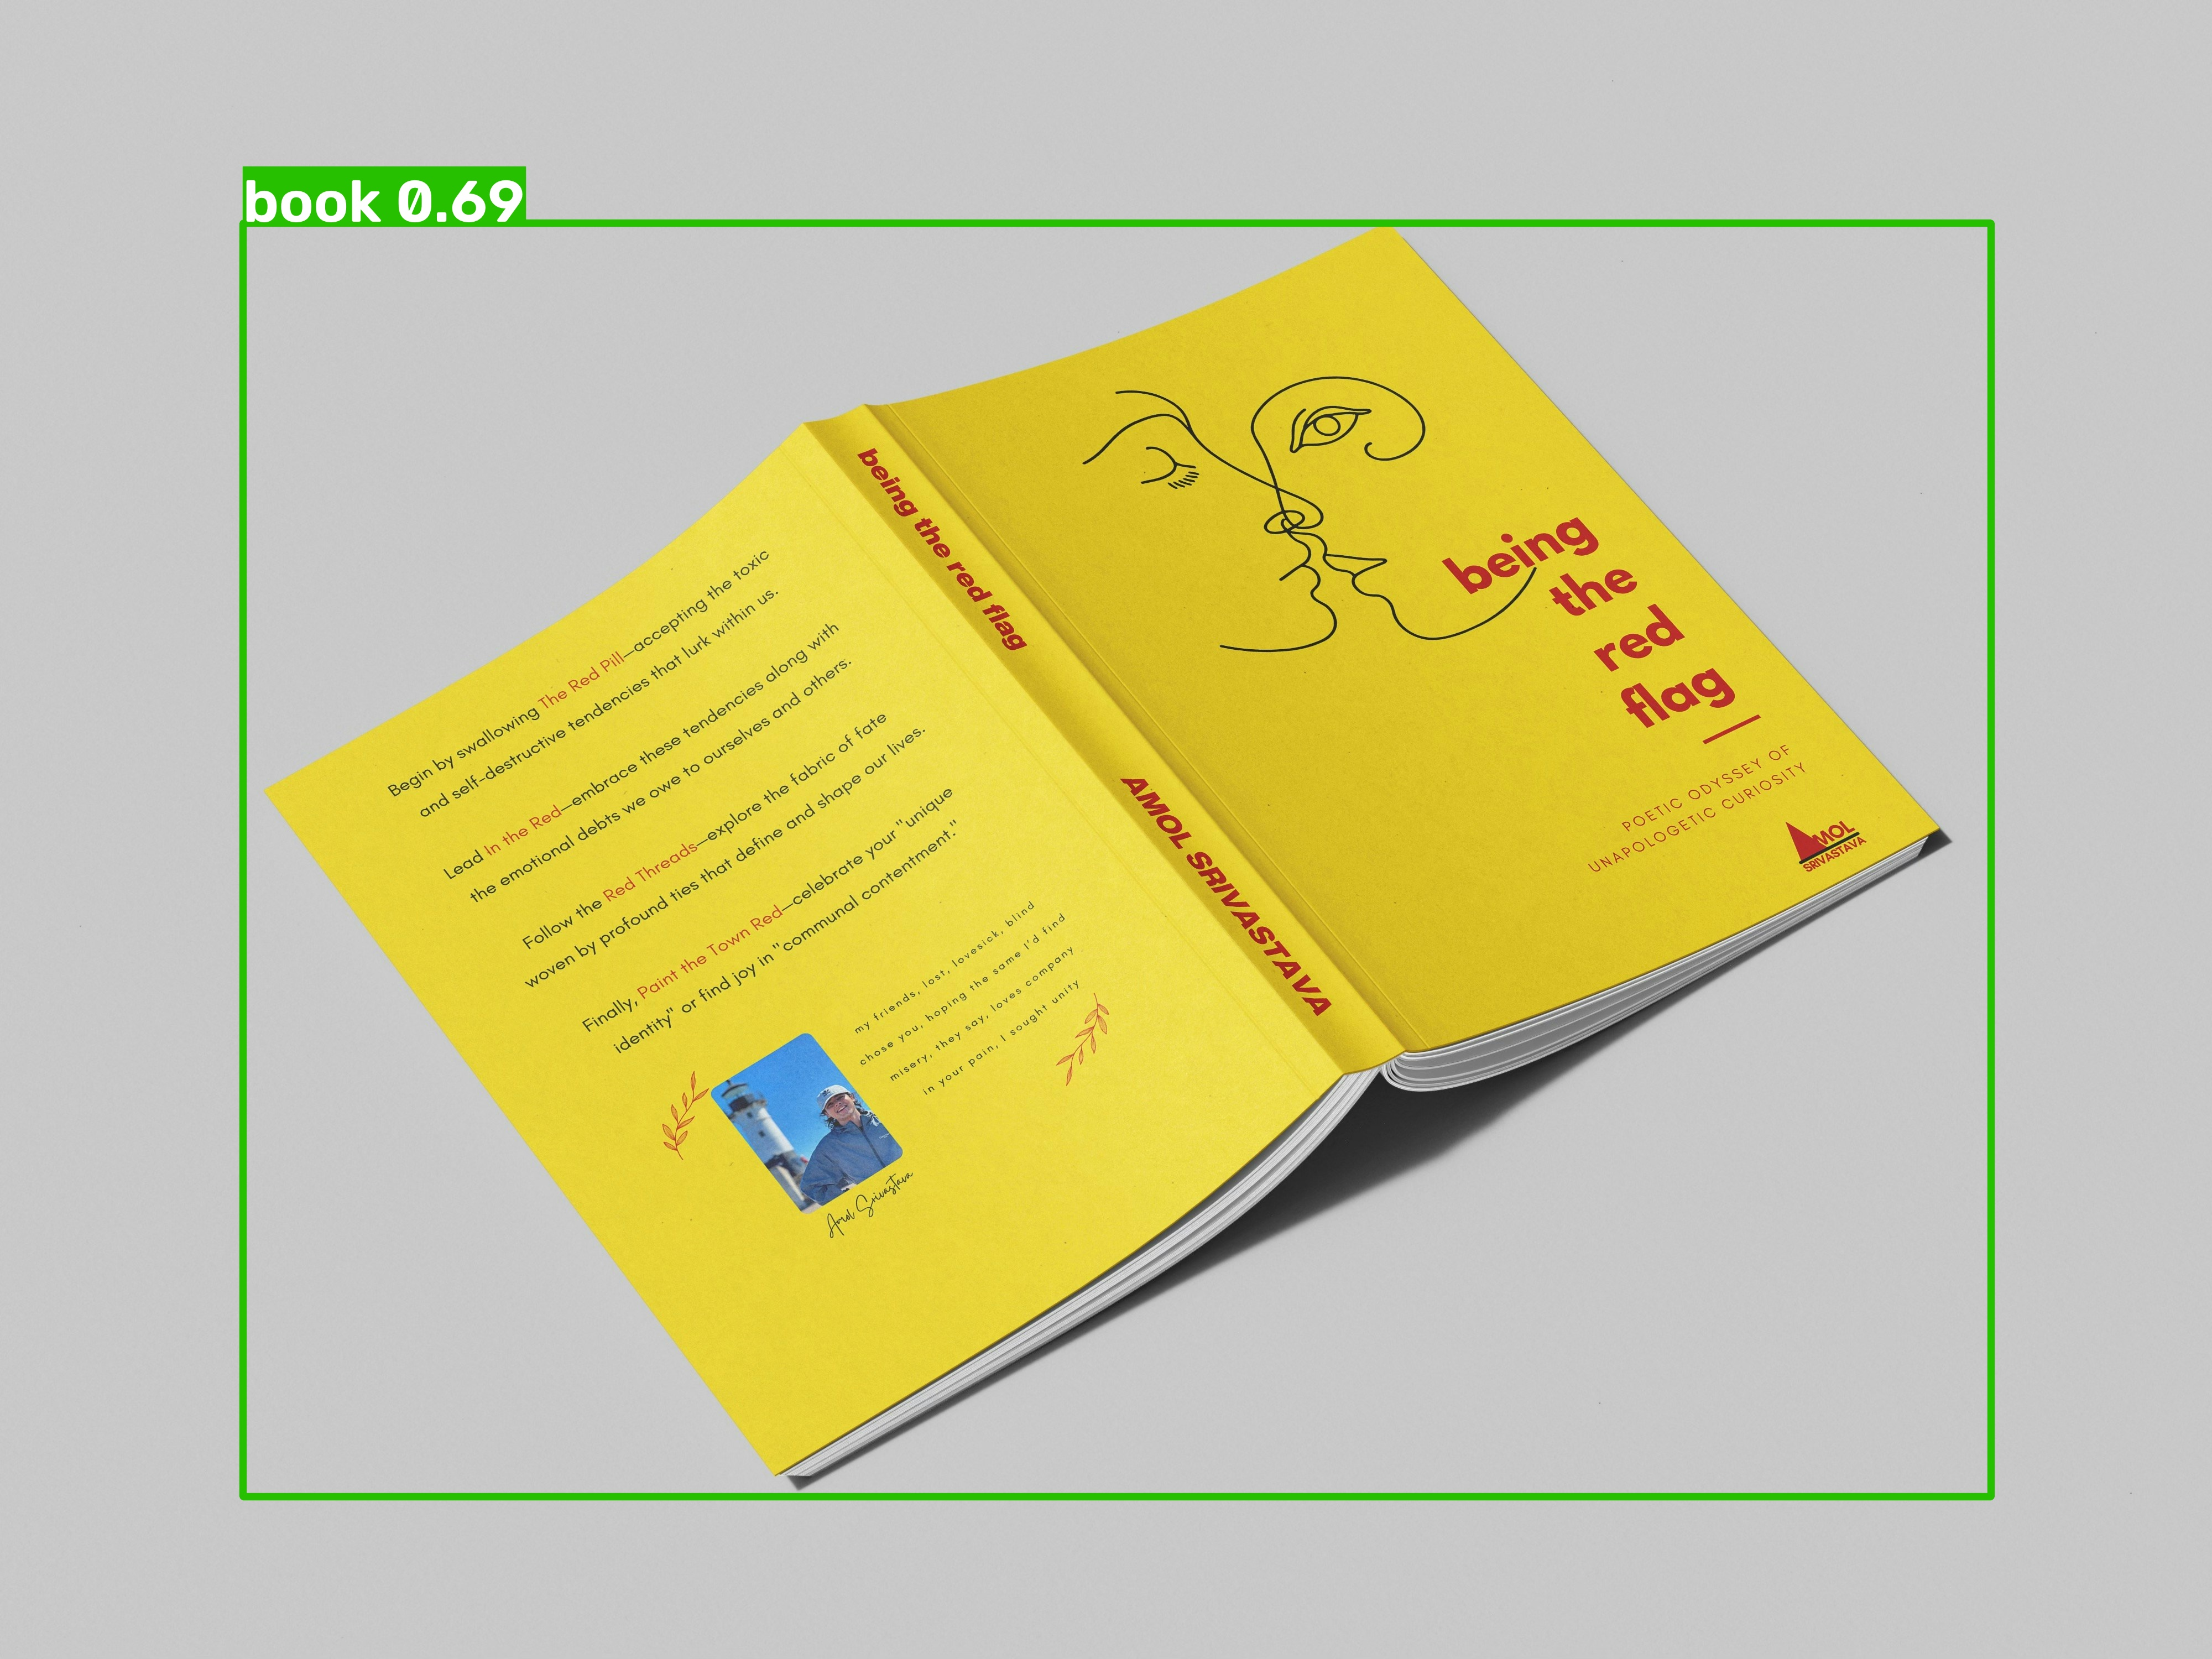

In [5]:
display(Image(filename="output_images/image1.jpg"))

In [6]:
image_path = "images/image1.jpg"

results = model(image_path)
boxes = results[0].boxes

for box in boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = model.names[class_id]

    print(f"Object : {class_name}")
    print(f"Confidence : {confidence:.2f}")
    print("-" * 30)


image 1/1 C:\Users\Localws\images\image1.jpg: 480x640 1 book, 521.9ms
Speed: 18.3ms preprocess, 521.9ms inference, 5.4ms postprocess per image at shape (1, 3, 480, 640)
Object : book
Confidence : 0.69
------------------------------


In [7]:
# Perform Dtection on Videos
video_folder = "videos"

video_files = [
    f for f in os.listdir(video_folder)
    if f.lower().endswith((".mp4", ".avi", ".mov"))
]

for video_name in video_files:

    video_path = os.path.join(video_folder, video_name)

    model.predict(
        source=video_path,
        save=True,
        project="output_videos",
        name=video_name.split(".")[0],
        exist_ok=True
    )

    print(f"Processed: {video_name}")

In [9]:
video_folder = "video"

video_files = [
    f for f in os.listdir(video_folder)
    if f.lower().endswith((".mp4", ".avi", ".mov"))
]

for video_name in video_files:

    video_path = os.path.join(video_folder, video_name)

    model.predict(
        source=video_path,
        save=True,
        project="output_videos",
        name=video_name.split(".")[0],
        exist_ok=True
    )

    print(f"Processed: {video_name}")


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/218) C:\Users\Localws\video\video1.mp4: 640x384 2 persons, 1 car, 1 bus, 880.2ms
video 1/1 (frame 2/218) C:\Users\Localws\video\video1.mp4: 640x384 2 persons, 1 car, 1 bus, 549.5ms
video 1/1 (frame 3/218) C:\Users\Localws\video\video1.mp4: 640x384 3 persons, 1 car, 1 bus, 689.7ms
video 1/1 (frame 4/218) C:\Users\Localws\video\video1.mp4: 640x384 3 persons, 1 car, 1 bus, 506.0ms
video 1/1 (frame 5/218) C:\Users\Localws\video\video1.mp4: 64